In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

In [2]:
from utils.db import fetch_data
import pandas as pd

In [3]:
query = """
SELECT 
    r.id AS ride_id,
    r.driver_id,
    r.ride_km,
    r.duration_min,
    r.fare,
    r.requested_at,
    rr.consistency_score,
    ds.shift_end
FROM rides r
JOIN ride_routes rr ON r.id = rr.ride_id
JOIN driver_shifts ds ON r.driver_id = ds.driver_id
LIMIT 1000;
"""

df = fetch_data(query)
df.head()

c:\Users\Admin\Desktop\start_end_consistency_engine\utils\db.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,ride_id,driver_id,ride_km,duration_min,fare,requested_at,consistency_score,shift_end
0,304ac178-3cb1-4b27-b56a-ab2ed55d129c,9d43a7a6-9418-4880-963a-6b195798bbb3,9.53,28,147.38,2026-03-22 21:17:56.593685+00:00,0.8761,2026-03-17 11:17:56.593685+00:00
1,304ac178-3cb1-4b27-b56a-ab2ed55d129c,9d43a7a6-9418-4880-963a-6b195798bbb3,9.53,28,147.38,2026-03-22 21:17:56.593685+00:00,0.8049,2026-03-17 11:17:56.593685+00:00
2,304ac178-3cb1-4b27-b56a-ab2ed55d129c,9d43a7a6-9418-4880-963a-6b195798bbb3,9.53,28,147.38,2026-03-22 21:17:56.593685+00:00,0.7268,2026-03-17 11:17:56.593685+00:00
3,304ac178-3cb1-4b27-b56a-ab2ed55d129c,9d43a7a6-9418-4880-963a-6b195798bbb3,9.53,28,147.38,2026-03-22 21:17:56.593685+00:00,0.9660,2026-03-17 11:17:56.593685+00:00
4,304ac178-3cb1-4b27-b56a-ab2ed55d129c,9d43a7a6-9418-4880-963a-6b195798bbb3,9.53,28,147.38,2026-03-22 21:17:56.593685+00:00,0.7623,2026-03-17 11:17:56.593685+00:00


In [4]:
df = df.dropna()
df.shape

(30, 8)

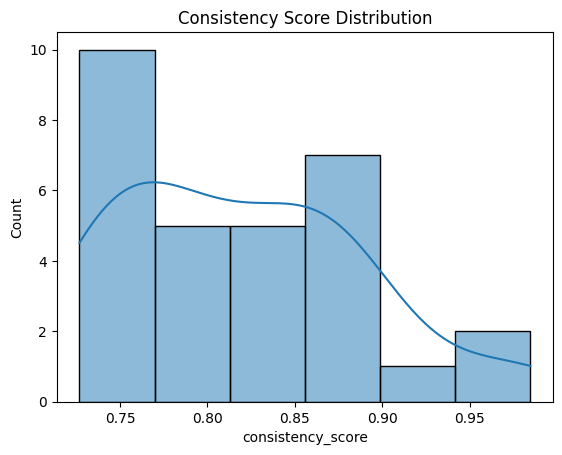

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df["consistency_score"], kde=True)
plt.title("Consistency Score Distribution")
plt.show()

In [6]:
df["requested_at"] = pd.to_datetime(df["requested_at"])
df["shift_end"] = pd.to_datetime(df["shift_end"])

df["hour"] = df["requested_at"].dt.hour

df["remaining_time"] = (
    df["shift_end"] - df["requested_at"]
).dt.total_seconds() / 60

In [7]:
df[["requested_at", "shift_end", "hour", "remaining_time"]].head()

,requested_at,shift_end,hour,remaining_time
0,2026-03-22 21:17:56.593685+00:00,2026-03-17 11:17:56.593685+00:00,21,-7800.0
1,2026-03-22 21:17:56.593685+00:00,2026-03-17 11:17:56.593685+00:00,21,-7800.0
2,2026-03-22 21:17:56.593685+00:00,2026-03-17 11:17:56.593685+00:00,21,-7800.0
3,2026-03-22 21:17:56.593685+00:00,2026-03-17 11:17:56.593685+00:00,21,-7800.0
4,2026-03-22 21:17:56.593685+00:00,2026-03-17 11:17:56.593685+00:00,21,-7800.0


In [8]:
# For now simple proxy (later we use Google Maps)
df["distance_proxy"] = df["ride_km"]

# Target variable
df["target"] = df["consistency_score"]

In [9]:
features = [
    "ride_km",
    "duration_min",
    "fare",
    "hour",
    "remaining_time",
    "distance_proxy"
]

X = df[features]
y = df["target"]

X.head()

,ride_km,duration_min,fare,hour,remaining_time,distance_proxy
0,9.53,28,147.38,21,-7800.0,9.53
1,9.53,28,147.38,21,-7800.0,9.53
2,9.53,28,147.38,21,-7800.0,9.53
3,9.53,28,147.38,21,-7800.0,9.53
4,9.53,28,147.38,21,-7800.0,9.53


In [10]:
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import mean_squared_error

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
model = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=7,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8
)

model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [14]:
import numpy as np

preds = model.predict(X_test)

mse = mean_squared_error(y_test, preds)
rmse = np.sqrt(mse)

print("RMSE:", rmse)

RMSE: 0.09727663531943419


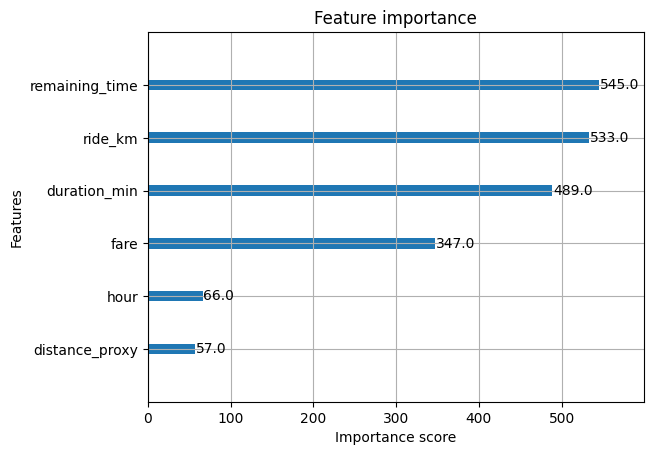

In [15]:
import matplotlib.pyplot as plt

xgb.plot_importance(model)
plt.show()

In [16]:
def recommend_rides(df, model):

    recommendations = []

    for _, row in df.iterrows():

        features = [
            row["ride_km"],
            row["duration_min"],
            row["fare"],
            row["hour"],
            row["remaining_time"],
            row["distance_proxy"]
        ]

        prob = model.predict([features])[0]

        # Simple scoring
        score = (2 * prob) + (0.5 * row["fare"]) - (0.3 * row["ride_km"])

        recommendations.append(score)

    df["score"] = recommendations

    return df.sort_values(by="score", ascending=False)

In [17]:
top_rides = recommend_rides(df.copy(), model)

top_rides.head(10)

,ride_id,driver_id,ride_km,duration_min,fare,requested_at,consistency_score,shift_end,hour,remaining_time,distance_proxy,target,score
26,a74d533b-e677-4121-8de8-e8d7c35582e4,9d43a7a6-9418-4880-963a-6b195798bbb3,13.95,12,398.40,2026-03-14 05:17:56.593685+00:00,0.8276,2026-03-17 11:17:56.593685+00:00,5,4680.0,13.95,0.8276,196.670227
25,2ead51b0-2b1f-4857-8c47-d920d03f817d,9d43a7a6-9418-4880-963a-6b195798bbb3,6.06,16,364.36,2026-03-14 13:17:56.593685+00:00,0.7436,2026-03-17 11:17:56.593685+00:00,13,4200.0,6.06,0.7436,181.848724
19,d4656c97-bf13-445e-ade4-32ac3fbc9458,9d43a7a6-9418-4880-963a-6b195798bbb3,8.74,25,314.95,2026-03-16 13:17:56.593685+00:00,0.7343,2026-03-17 11:17:56.593685+00:00,13,1320.0,8.74,0.7343,156.324478
20,bc6d11d0-745d-407a-a9cf-89d2b7bd8f91,9d43a7a6-9418-4880-963a-6b195798bbb3,18.13,29,284.89,2026-03-16 05:17:56.593685+00:00,0.8863,2026-03-17 11:17:56.593685+00:00,5,1800.0,18.13,0.8863,138.776443
28,285fa596-133c-4141-8121-6d9d2b0ef64b,9d43a7a6-9418-4880-963a-6b195798bbb3,6.25,14,263.56,2026-03-13 13:17:56.593685+00:00,0.8464,2026-03-17 11:17:56.593685+00:00,13,5640.0,6.25,0.8464,131.597733
27,d517ed06-abee-4465-823e-84b90b46ef99,9d43a7a6-9418-4880-963a-6b195798bbb3,16.17,40,253.32,2026-03-13 21:17:56.593685+00:00,0.7880,2026-03-17 11:17:56.593685+00:00,21,5160.0,16.17,0.7880,123.459183
16,8b52ceef-0fa5-43a8-af42-4ccff2340d61,9d43a7a6-9418-4880-963a-6b195798bbb3,12.74,35,219.80,2026-03-17 13:17:56.593685+00:00,0.8130,2026-03-17 11:17:56.593685+00:00,13,-120.0,12.74,0.8130,107.703972
18,5aa4a4de-30b6-488b-bf95-4b6ab417014a,9d43a7a6-9418-4880-963a-6b195798bbb3,18.44,45,213.20,2026-03-16 21:17:56.593685+00:00,0.7937,2026-03-17 11:17:56.593685+00:00,21,840.0,18.44,0.7937,102.655884
24,f6544421-df93-495d-95b8-68cd3ab437ec,9d43a7a6-9418-4880-963a-6b195798bbb3,15.00,27,208.80,2026-03-14 21:17:56.593685+00:00,0.8394,2026-03-17 11:17:56.593685+00:00,21,3720.0,15.00,0.8394,101.578712
22,90ba4070-9fd3-4fdf-887d-3bd9de53ba2c,9d43a7a6-9418-4880-963a-6b195798bbb3,14.75,14,192.90,2026-03-15 13:17:56.593685+00:00,0.8829,2026-03-17 11:17:56.593685+00:00,13,2760.0,14.75,0.8829,93.789482


In [18]:
def is_feasible(row):
    return row["remaining_time"] > row["duration_min"]


df["feasible"] = df.apply(is_feasible, axis=1)

df = df[df["feasible"] == True]

In [19]:
top_rides = recommend_rides(df.copy(), model)
top_rides.head(10)

,ride_id,driver_id,ride_km,duration_min,fare,requested_at,consistency_score,shift_end,hour,remaining_time,distance_proxy,target,feasible,score
26,a74d533b-e677-4121-8de8-e8d7c35582e4,9d43a7a6-9418-4880-963a-6b195798bbb3,13.95,12,398.40,2026-03-14 05:17:56.593685+00:00,0.8276,2026-03-17 11:17:56.593685+00:00,5,4680.0,13.95,0.8276,True,196.670227
25,2ead51b0-2b1f-4857-8c47-d920d03f817d,9d43a7a6-9418-4880-963a-6b195798bbb3,6.06,16,364.36,2026-03-14 13:17:56.593685+00:00,0.7436,2026-03-17 11:17:56.593685+00:00,13,4200.0,6.06,0.7436,True,181.848724
19,d4656c97-bf13-445e-ade4-32ac3fbc9458,9d43a7a6-9418-4880-963a-6b195798bbb3,8.74,25,314.95,2026-03-16 13:17:56.593685+00:00,0.7343,2026-03-17 11:17:56.593685+00:00,13,1320.0,8.74,0.7343,True,156.324478
20,bc6d11d0-745d-407a-a9cf-89d2b7bd8f91,9d43a7a6-9418-4880-963a-6b195798bbb3,18.13,29,284.89,2026-03-16 05:17:56.593685+00:00,0.8863,2026-03-17 11:17:56.593685+00:00,5,1800.0,18.13,0.8863,True,138.776443
28,285fa596-133c-4141-8121-6d9d2b0ef64b,9d43a7a6-9418-4880-963a-6b195798bbb3,6.25,14,263.56,2026-03-13 13:17:56.593685+00:00,0.8464,2026-03-17 11:17:56.593685+00:00,13,5640.0,6.25,0.8464,True,131.597733
27,d517ed06-abee-4465-823e-84b90b46ef99,9d43a7a6-9418-4880-963a-6b195798bbb3,16.17,40,253.32,2026-03-13 21:17:56.593685+00:00,0.7880,2026-03-17 11:17:56.593685+00:00,21,5160.0,16.17,0.7880,True,123.459183
18,5aa4a4de-30b6-488b-bf95-4b6ab417014a,9d43a7a6-9418-4880-963a-6b195798bbb3,18.44,45,213.20,2026-03-16 21:17:56.593685+00:00,0.7937,2026-03-17 11:17:56.593685+00:00,21,840.0,18.44,0.7937,True,102.655884
24,f6544421-df93-495d-95b8-68cd3ab437ec,9d43a7a6-9418-4880-963a-6b195798bbb3,15.00,27,208.80,2026-03-14 21:17:56.593685+00:00,0.8394,2026-03-17 11:17:56.593685+00:00,21,3720.0,15.00,0.8394,True,101.578712
22,90ba4070-9fd3-4fdf-887d-3bd9de53ba2c,9d43a7a6-9418-4880-963a-6b195798bbb3,14.75,14,192.90,2026-03-15 13:17:56.593685+00:00,0.8829,2026-03-17 11:17:56.593685+00:00,13,2760.0,14.75,0.8829,True,93.789482
17,efb22d37-62bf-4235-93d8-a6603e879411,9d43a7a6-9418-4880-963a-6b195798bbb3,11.58,49,160.32,2026-03-17 05:17:56.593685+00:00,0.7335,2026-03-17 11:17:56.593685+00:00,5,360.0,11.58,0.7335,True,78.310890


In [20]:
DEPOT_LAT = 18.5314
DEPOT_LNG = 73.8446

In [21]:
import math

def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km
    
    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(lon2 - lon1)
    
    a = math.sin(dlat/2)**2 + math.cos(math.radians(lat1)) \
        * math.cos(math.radians(lat2)) * math.sin(dlon/2)**2
    
    return 2 * R * math.atan2(math.sqrt(a), math.sqrt(1-a))

In [22]:
import numpy as np

# Simulate pickup & drop coordinates (temporary)
df["pickup_lat"] = 18.5 + np.random.rand(len(df)) * 0.1
df["pickup_lng"] = 73.8 + np.random.rand(len(df)) * 0.1

df["drop_lat"] = 18.5 + np.random.rand(len(df)) * 0.1
df["drop_lng"] = 73.8 + np.random.rand(len(df)) * 0.1

In [23]:
df["drop_to_depot"] = df.apply(
    lambda x: haversine(x["drop_lat"], x["drop_lng"], DEPOT_LAT, DEPOT_LNG),
    axis=1
)

In [24]:
AVG_SPEED = 30  # km/h

df["return_time"] = (df["drop_to_depot"] / AVG_SPEED) * 60  # minutes

In [25]:
df["feasible"] = (
    df["duration_min"] + df["return_time"]
) <= df["remaining_time"]

df = df[df["feasible"] == True]

In [26]:
features = [
    "ride_km",
    "duration_min",
    "fare",
    "hour",
    "remaining_time",
    "drop_to_depot"
]

X = df[features]
y = df["target"]

In [27]:
model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [28]:
def recommend_rides(df, model):

    scores = []

    for _, row in df.iterrows():

        features = [
            row["ride_km"],
            row["duration_min"],
            row["fare"],
            row["hour"],
            row["remaining_time"],
            row["drop_to_depot"]
        ]

        prob = model.predict([features])[0]

        score = (
            2.5 * prob
            + 0.5 * row["fare"]
            - 1.0 * row["drop_to_depot"]
        )

        scores.append(score)

    df["score"] = scores

    return df.sort_values(by="score", ascending=False)

In [29]:
top_rides = recommend_rides(df.copy(), model)
top_rides.head(10)

,ride_id,driver_id,ride_km,duration_min,fare,requested_at,consistency_score,shift_end,hour,remaining_time,distance_proxy,target,feasible,pickup_lat,pickup_lng,drop_lat,drop_lng,drop_to_depot,return_time,score
26,a74d533b-e677-4121-8de8-e8d7c35582e4,9d43a7a6-9418-4880-963a-6b195798bbb3,13.95,12,398.40,2026-03-14 05:17:56.593685+00:00,0.8276,2026-03-17 11:17:56.593685+00:00,5,4680.0,13.95,0.8276,True,18.561804,73.897841,18.531816,73.893949,5.203011,10.406022,196.064606
25,2ead51b0-2b1f-4857-8c47-d920d03f817d,9d43a7a6-9418-4880-963a-6b195798bbb3,6.06,16,364.36,2026-03-14 13:17:56.593685+00:00,0.7436,2026-03-17 11:17:56.593685+00:00,13,4200.0,6.06,0.7436,True,18.510355,73.821607,18.571584,73.821695,5.078906,10.157813,178.959503
19,d4656c97-bf13-445e-ade4-32ac3fbc9458,9d43a7a6-9418-4880-963a-6b195798bbb3,8.74,25,314.95,2026-03-16 13:17:56.593685+00:00,0.7343,2026-03-17 11:17:56.593685+00:00,13,1320.0,8.74,0.7343,True,18.542428,73.853239,18.531330,73.851140,0.689519,1.379038,158.624832
20,bc6d11d0-745d-407a-a9cf-89d2b7bd8f91,9d43a7a6-9418-4880-963a-6b195798bbb3,18.13,29,284.89,2026-03-16 05:17:56.593685+00:00,0.8863,2026-03-17 11:17:56.593685+00:00,5,1800.0,18.13,0.8863,True,18.515796,73.805464,18.537569,73.884641,4.276756,8.553512,140.359879
28,285fa596-133c-4141-8121-6d9d2b0ef64b,9d43a7a6-9418-4880-963a-6b195798bbb3,6.25,14,263.56,2026-03-13 13:17:56.593685+00:00,0.8464,2026-03-17 11:17:56.593685+00:00,13,5640.0,6.25,0.8464,True,18.554774,73.869634,18.560012,73.880768,4.965832,9.931664,128.929169
27,d517ed06-abee-4465-823e-84b90b46ef99,9d43a7a6-9418-4880-963a-6b195798bbb3,16.17,40,253.32,2026-03-13 21:17:56.593685+00:00,0.7880,2026-03-17 11:17:56.593685+00:00,21,5160.0,16.17,0.7880,True,18.503097,73.843372,18.536373,73.848318,0.677787,1.355574,128.039230
24,f6544421-df93-495d-95b8-68cd3ab437ec,9d43a7a6-9418-4880-963a-6b195798bbb3,15.00,27,208.80,2026-03-14 21:17:56.593685+00:00,0.8394,2026-03-17 11:17:56.593685+00:00,21,3720.0,15.00,0.8394,True,18.570968,73.823801,18.515334,73.852395,1.966469,3.932937,104.520538
18,5aa4a4de-30b6-488b-bf95-4b6ab417014a,9d43a7a6-9418-4880-963a-6b195798bbb3,18.44,45,213.20,2026-03-16 21:17:56.593685+00:00,0.7937,2026-03-17 11:17:56.593685+00:00,21,840.0,18.44,0.7937,True,18.567380,73.879034,18.576979,73.873463,5.911334,11.822668,102.675179
22,90ba4070-9fd3-4fdf-887d-3bd9de53ba2c,9d43a7a6-9418-4880-963a-6b195798bbb3,14.75,14,192.90,2026-03-15 13:17:56.593685+00:00,0.8829,2026-03-17 11:17:56.593685+00:00,13,2760.0,14.75,0.8829,True,18.598386,73.862566,18.593127,73.807183,7.916259,15.832517,90.724747
17,efb22d37-62bf-4235-93d8-a6603e879411,9d43a7a6-9418-4880-963a-6b195798bbb3,11.58,49,160.32,2026-03-17 05:17:56.593685+00:00,0.7335,2026-03-17 11:17:56.593685+00:00,5,360.0,11.58,0.7335,True,18.526198,73.815098,18.544314,73.847997,1.479969,2.959938,80.708870


In [30]:
import joblib

joblib.dump(model, "../models/xgb_model.pkl")

['../models/xgb_model.pkl']